<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
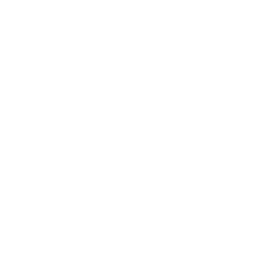
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Classificação de Subtipo Molecular a partir da Expressão Gênica</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Biotecnologia / Oncologia Genômica &nbsp;|&nbsp; Março de 2026</p>
</div>
</div>
</div>

## Resumo executivo

Classifique amostras de biópsia tumoral em quatro subtipos moleculares (Luminal-A, Luminal-B, HER2-enriched, Basal-like) usando painéis de biomarcadores de expressão gênica. Aplique análise discriminante canônica para reduzir o espaço de expressão de alta dimensão a eixos de variação interpretáveis. Use MANOVA para testar se os perfis médios de expressão diferem significativamente entre os subtipos. Faça validação cruzada para estimar a confiabilidade da classificação como apoio à decisão clínica na seleção da via de tratamento.

## Fontes de dados

| Fonte | Descrição | Registros |
|--------|-------------|--------|
| WORK.GENE_EXPR | Expressão gênica tumoral com rótulos de subtipo | 100 |
| WORK.NEW_BIOPSIES | Amostras de biópsia não classificadas | 100 |


---

In [1]:
/* --------------------------------------------------------
   Gerar conjunto de dados sintético de expressão gênica
   com quatro subtipos moleculares
   -------------------------------------------------------- */
DADOS work.gene_expr;
    CHAMAR streaminit(42);
    COMPRIMENTO mol_subtype $12;
    VETOR subtype_list[4] $12 _temporary_ ('LUMINAL_A' 'LUMINAL_B' 'HER2_ENRICH' 'BASAL_LIKE');
    FAZER sample_id = 1 ATÉ 100;
        tumor_id = cat('TUM-', PUT(sample_id, z5.));
        sub_idx = int(rand('uniform') * 4) + 1;
        mol_subtype = subtype_list[sub_idx];

        /* Marcadores de expressão gênica simulados (escala log2) */
        SELECIONAR (mol_subtype);
            QUANDO ('LUMINAL_A') FAZER;
                esr1_expr = round(rand('normal', 11.5, 1.2), 0.01);
                pgr_expr = round(rand('normal', 9.8, 1.5), 0.01);
                erbb2_expr = round(rand('normal', 7.2, 0.9), 0.01);
                ki67_expr = round(rand('normal', 6.0, 1.0), 0.01);
                egfr_expr = round(rand('normal', 6.5, 1.1), 0.01);
                cytokeratin5 = round(rand('normal', 5.0, 0.8), 0.01);
                tp53_mut_load = round(rand('poisson', 1.5), 1);
                prolif_score = round(rand('normal', 3.2, 0.8), 0.01);
            FIM;
            QUANDO ('LUMINAL_B') FAZER;
                esr1_expr = round(rand('normal', 10.0, 1.4), 0.01);
                pgr_expr = round(rand('normal', 7.5, 1.8), 0.01);
                erbb2_expr = round(rand('normal', 8.5, 1.2), 0.01);
                ki67_expr = round(rand('normal', 8.5, 1.2), 0.01);
                egfr_expr = round(rand('normal', 7.0, 1.0), 0.01);
                cytokeratin5 = round(rand('normal', 5.5, 0.9), 0.01);
                tp53_mut_load = round(rand('poisson', 3.0), 1);
                prolif_score = round(rand('normal', 6.0, 1.0), 0.01);
            FIM;
            QUANDO ('HER2_ENRICH') FAZER;
                esr1_expr = round(rand('normal', 6.5, 1.5), 0.01);
                pgr_expr = round(rand('normal', 5.0, 1.2), 0.01);
                erbb2_expr = round(rand('normal', 13.0, 1.0), 0.01);
                ki67_expr = round(rand('normal', 9.0, 1.3), 0.01);
                egfr_expr = round(rand('normal', 8.5, 1.2), 0.01);
                cytokeratin5 = round(rand('normal', 6.0, 1.0), 0.01);
                tp53_mut_load = round(rand('poisson', 5.0), 1);
                prolif_score = round(rand('normal', 7.5, 1.1), 0.01);
            FIM;
            QUANDO ('BASAL_LIKE') FAZER;
                esr1_expr = round(rand('normal', 4.5, 1.3), 0.01);
                pgr_expr = round(rand('normal', 3.8, 1.0), 0.01);
                erbb2_expr = round(rand('normal', 6.0, 1.1), 0.01);
                ki67_expr = round(rand('normal', 10.5, 1.4), 0.01);
                egfr_expr = round(rand('normal', 11.0, 1.3), 0.01);
                cytokeratin5 = round(rand('normal', 10.5, 1.2), 0.01);
                tp53_mut_load = round(rand('poisson', 7.0), 1);
                prolif_score = round(rand('normal', 8.8, 1.2), 0.01);
            FIM;
            OUTROS;
        FIM;
        SAÍDA;
    FIM;
    REMOVER sub_idx;
    RÓTULO mol_subtype='Subtipo Molecular'
           esr1_expr='Expressão ESR1 (log2)'
           pgr_expr='Expressão PGR (log2)'
           erbb2_expr='Expressão ERBB2 (log2)'
           ki67_expr='Expressão KI67 (log2)'
           egfr_expr='Expressão EGFR (log2)'
           cytokeratin5='Citoqueratina 5 (log2)'
           tp53_mut_load='Carga Mutacional TP53'
           prolif_score='Escore de Proliferação'
           tumor_id='ID do Tumor';
EXECUTAR;


NOTE: DATA work.gene_expr


NOTE: Wrote work.gene_expr (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Gerar amostras de biópsia não classificadas
   -------------------------------------------------------- */
DADOS work.new_biopsies;
    CHAMAR streaminit(55);
    FAZER sample_id = 5001 ATÉ 5100;
        tumor_id = cat('TUM-', PUT(sample_id, z5.));
        esr1_expr = round(rand('normal', 8.0, 3.0), 0.01);
        pgr_expr = round(rand('normal', 6.5, 3.0), 0.01);
        erbb2_expr = round(rand('normal', 8.5, 2.5), 0.01);
        ki67_expr = round(rand('normal', 8.0, 2.0), 0.01);
        egfr_expr = round(rand('normal', 8.0, 2.0), 0.01);
        cytokeratin5 = round(rand('normal', 7.0, 2.5), 0.01);
        tp53_mut_load = round(rand('poisson', 4.0), 1);
        prolif_score = round(rand('normal', 6.0, 2.5), 0.01);
        mol_subtype = '';
        SAÍDA;
    FIM;
    RÓTULO mol_subtype='Subtipo Molecular'
           esr1_expr='Expressão ESR1 (log2)'
           pgr_expr='Expressão PGR (log2)'
           erbb2_expr='Expressão ERBB2 (log2)'
           ki67_expr='Expressão KI67 (log2)'
           egfr_expr='Expressão EGFR (log2)'
           cytokeratin5='Citoqueratina 5 (log2)'
           tp53_mut_load='Carga Mutacional TP53'
           prolif_score='Escore de Proliferação'
           tumor_id='ID do Tumor';
EXECUTAR;


NOTE: DATA work.new_biopsies


NOTE: Wrote work.new_biopsies (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

                                          Distribuição de Subtipos Moleculares                                          

                                                   The FREQ Procedure

Subtipo Molecular    Frequency    Percent
------------------------------------------
BASAL_LIKE                  24     24.00
HER2_ENRICH                 22     22.00
LUMINAL_A                   25     25.00
LUMINAL_B                   29     29.00
                                    Resumo da Expressão Gênica por Subtipo Molecular                                    

                                                  The MEANS Procedure

                                  Analysis Variable : esr1_expr Expressão ESR1 (log2)

        Subtipo Molecular          N Obs           Mean        Std Dev
        --------------------------------------------------------------
        BASAL_LIKE                    24      4.5479167      1.2257100
        HER2_ENRICH                   22      7.1318182      1.44


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mol_subtype.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


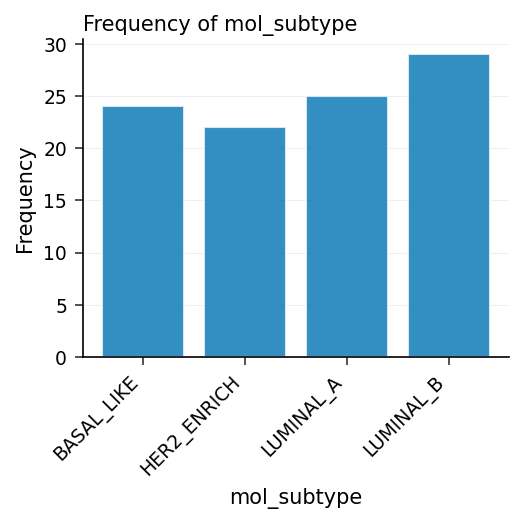

In [3]:
/* --------------------------------------------------------
   Distribuição de subtipos de base e perfis de expressão
   -------------------------------------------------------- */
PROCEDIMENTO FREQUÊNCIAS DADOS=work.gene_expr;
    TABLES mol_subtype / nocum;
    RÓTULO mol_subtype='Subtipo Molecular';
    TÍTULO 'Distribuição de Subtipos Moleculares';
EXECUTAR;

PROCEDIMENTO MÉDIAS DADOS=work.gene_expr n mean std;
    CLASSE mol_subtype;
    VARIÁVEL esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    RÓTULO mol_subtype='Subtipo Molecular'
           esr1_expr='Expressão ESR1 (log2)'
           pgr_expr='Expressão PGR (log2)'
           erbb2_expr='Expressão ERBB2 (log2)'
           ki67_expr='Expressão KI67 (log2)'
           egfr_expr='Expressão EGFR (log2)'
           cytokeratin5='Citoqueratina 5 (log2)'
           tp53_mut_load='Carga Mutacional TP53'
           prolif_score='Escore de Proliferação'
           tumor_id='ID do Tumor';
    TÍTULO 'Resumo da Expressão Gênica por Subtipo Molecular';
EXECUTAR;

---

In [4]:
/* --------------------------------------------------------
   Análise discriminante canônica com MANOVA
   CANONICAL extrai eixos discriminantes para visualização.
   MANOVA testa a separação global das médias entre subtipos.
   -------------------------------------------------------- */
PROCEDIMENTO DISCRIM DADOS=work.gene_expr
        METHOD=NORMAL
        pool=TEST
        canonical
        MANOVA
        crossvalidate
        out=work.subtype_canonical
        OUTSTAT=work.subtype_stats;
    CLASSE mol_subtype;
    VARIÁVEL esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    RÓTULO mol_subtype='Subtipo Molecular'
           esr1_expr='Expressão ESR1 (log2)'
           pgr_expr='Expressão PGR (log2)'
           erbb2_expr='Expressão ERBB2 (log2)'
           ki67_expr='Expressão KI67 (log2)'
           egfr_expr='Expressão EGFR (log2)'
           cytokeratin5='Citoqueratina 5 (log2)'
           tp53_mut_load='Carga Mutacional TP53'
           prolif_score='Escore de Proliferação'
           tumor_id='ID do Tumor';
    TÍTULO 'Análise Discriminante Canônica: Subtipos Moleculares Tumorais';
    title2 'Teste MANOVA das Diferenças de Perfis Médios de Expressão';
EXECUTAR;

                                    Resumo da Expressão Gênica por Subtipo Molecular                                    


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Cross-Validation Error Rate: 0.0400
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: Multivariate Statistics:
NOTE:   Wilks' Lambda: 0.0037 (p = 0.000000)
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


---

                                    Resumo da Expressão Gênica por Subtipo Molecular                                    




NOTE: PROC SGPLOT data=work.subtype_canonical

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


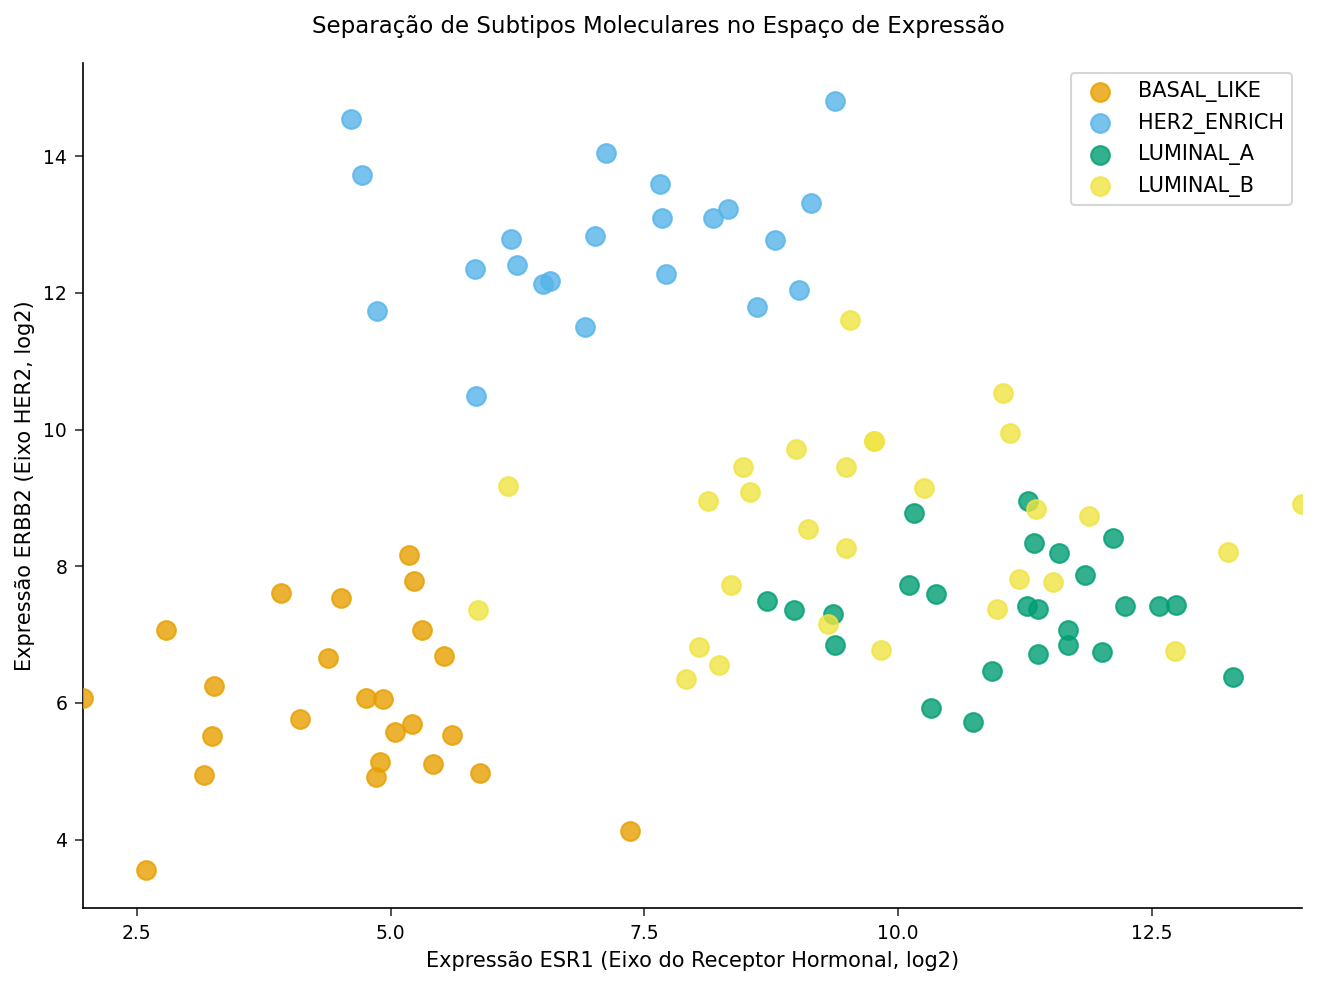

In [5]:
/* --------------------------------------------------------
   Separação de subtipos no espaço de expressão
   ESR1 (eixo do receptor hormonal) vs ERBB2 (eixo HER2),
   extraído do conjunto OUT= da análise discriminante.
   -------------------------------------------------------- */
PROCEDIMENTO SGPLOT DADOS=work.subtype_canonical;
    SCATTER x=esr1_expr y=erbb2_expr / GROUP=mol_subtype
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.2;
    XAXIS RÓTULO='Expressão ESR1 (Eixo do Receptor Hormonal, log2)';
    YAXIS RÓTULO='Expressão ERBB2 (Eixo HER2, log2)';
    TÍTULO 'Separação de Subtipos Moleculares no Espaço de Expressão';
EXECUTAR;


In [6]:
/* --------------------------------------------------------
   Classificar amostras de biópsia não tipadas
   -------------------------------------------------------- */
PROCEDIMENTO DISCRIM DADOS=work.gene_expr
        testdata=work.new_biopsies
        testout=work.classified_biopsies
        METHOD=NORMAL
        pool=TEST
        canonical;
    CLASSE mol_subtype;
    VARIÁVEL esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    RÓTULO mol_subtype='Subtipo Molecular'
           esr1_expr='Expressão ESR1 (log2)'
           pgr_expr='Expressão PGR (log2)'
           erbb2_expr='Expressão ERBB2 (log2)'
           ki67_expr='Expressão KI67 (log2)'
           egfr_expr='Expressão EGFR (log2)'
           cytokeratin5='Citoqueratina 5 (log2)'
           tp53_mut_load='Carga Mutacional TP53'
           prolif_score='Escore de Proliferação'
           tumor_id='ID do Tumor';
    TÍTULO 'Classificação de Subtipo Molecular de Novas Biópsias';
EXECUTAR;

                                    Resumo da Expressão Gênica por Subtipo Molecular                                    


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


                             Distribuição Prevista de Subtipos Moleculares: Novas Biópsias                              

                                                   The FREQ Procedure

Subtipo Molecular Previsto    Frequency    Percent
---------------------------------------------------
BASAL_LIKE                            7      7.00
HER2_ENRICH                          47     47.00
LUMINAL_A                            10     10.00
LUMINAL_B                            36     36.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq__into_.spec.json
NOTE: PROC FREQ statement used.


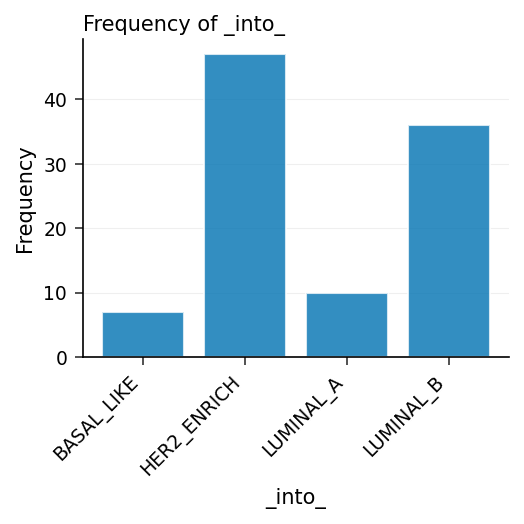

In [7]:
/* --------------------------------------------------------
   Distribuição da classificação para novas biópsias
   -------------------------------------------------------- */
PROCEDIMENTO FREQUÊNCIAS DADOS=work.classified_biopsies;
    TABLES _into_ / nocum;
    RÓTULO _into_='Subtipo Molecular Previsto';
    TÍTULO 'Distribuição Prevista de Subtipos Moleculares: Novas Biópsias';
EXECUTAR;

---

### Interpretação

O teste MANOVA confirma uma diferença altamente significativa nos perfis médios de expressão gênica entre os quatro subtipos moleculares: Wilks' Lambda = 0.0037 com p < 0.0001, de modo que os subtipos ocupam regiões claramente distintas do espaço de expressão de oito marcadores. Essa separação é visível no gráfico de dispersão do espaço de expressão, onde os tumores Luminal ficam no alto do eixo ESR1 (receptor hormonal), enquanto os tumores HER2-enriched avançam para o topo do eixo ERBB2 e os tumores Basal-like caem para o canto inferior esquerdo de ambos. A classificação por ressubstituição dos 100 tumores rotulados é perfeita (0% de erro aparente), e a validação cruzada leave-one-out situa a taxa de erro em apenas 4% — uma acurácia validada por validação cruzada honesta de 96%, com cada subtipo corretamente recuperado na matriz de confusão validada. Aplicar o classificador treinado às 100 biópsias não rotuladas atribui 47 a HER2-enriched, 36 a Luminal-B, 10 a Luminal-A e 7 a Basal-like; a inclinação para HER2-enriched reflete as leituras elevadas de ERBB2 e de proliferação do painel de biópsias. Essas classificações de subtipo orientam a seleção da via de tratamento: terapia endócrina para tumores Luminal, agentes anti-HER2 direcionados para o grupo HER2-enriched, e regimes de quimioterapia para tumores Basal-like.


---

In [8]:
/* --------------------------------------------------------
   Exportar biópsias classificadas para planejamento de tratamento
   -------------------------------------------------------- */
PROCEDIMENTO EXPORT DADOS=work.classified_biopsies
    OUTFILE='classified_biopsy_subtypes.csv'
    DBMS=csv REPLACE;
EXECUTAR;

PROCEDIMENTO EXPORT DADOS=work.subtype_canonical
    OUTFILE='canonical_subtype_scores.csv'
    DBMS=csv REPLACE;
EXECUTAR;


NOTE: PROC EXPORT data=work.classified_biopsies outfile=classified_biopsy_subtypes.csv

NOTE: Exported 100 rows to classified_biopsy_subtypes.csv.
NOTE: PROC EXPORT data=work.subtype_canonical outfile=canonical_subtype_scores.csv

NOTE: Exported 100 rows to canonical_subtype_scores.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desenvolvido por <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>